In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('train.csv')
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [5]:
df.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [6]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1})

In [7]:
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,0,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,1,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,1,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,0,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,1,38,166.0,61.0,25.0,102.0,40.6,146.0


In [8]:
df["Sex"].unique()

array([0, 1])

In [11]:
X=df.drop(["Calories","id"], axis =1)
y=df["Calories"]

In [12]:
X.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,36,189.0,82.0,26.0,101.0,41.0
1,1,64,163.0,60.0,8.0,85.0,39.7
2,1,51,161.0,64.0,7.0,84.0,39.8
3,0,20,192.0,90.0,25.0,105.0,40.7
4,1,38,166.0,61.0,25.0,102.0,40.6


In [13]:
y.head()

0    150.0
1     34.0
2     29.0
3    140.0
4    146.0
Name: Calories, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
from sklearn.linear_model import LinearRegression
lr =LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred=lr.predict(X_test)

In [21]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
mean_absolute_error(y_test,y_pred)

0.9684446417027913


8.082859019684404

In [22]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

,Feature,Coefficient
0,Sex,1.688006
1,Age,0.532317
2,Height,-0.146744
3,Weight,0.269907
4,Duration,6.759044
5,Heart_Rate,1.951159
6,Body_Temp,-18.199123


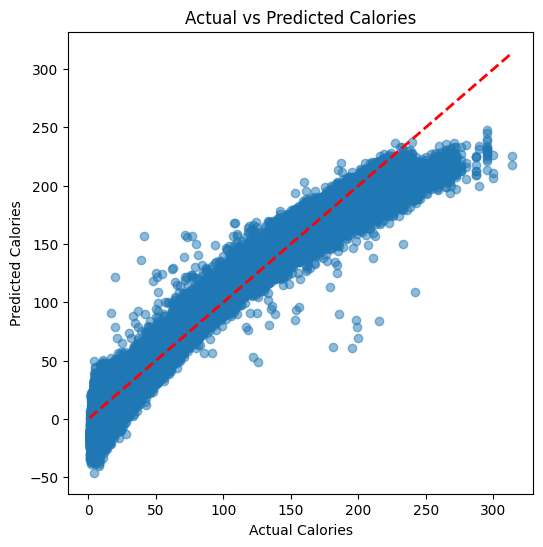

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")

plt.show()